# **Credit Card Fraud Detection**

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


In [ ]:
np.random.seed(42)

n_samples = 5000

transaction_amount = np.random.exponential(scale=200, size=n_samples)
transaction_time = np.random.randint(0, 24, size=n_samples)
customer_age = np.random.randint(18, 70, size=n_samples)
merchant_risk = np.random.rand(n_samples)
num_prev_transactions = np.random.poisson(lam=3, size=n_samples)

df = pd.DataFrame({
    "transaction_amount": transaction_amount,
    "transaction_time": transaction_time,
    "customer_age": customer_age,
    "merchant_risk": merchant_risk,
    "num_prev_transactions": num_prev_transactions
})

df.head()

,transaction_amount,transaction_time,customer_age,merchant_risk,num_prev_transactions
0,93.853618,18,25,0.629510,3
1,602.024286,7,24,0.488706,1
2,263.349139,6,51,0.889964,3
3,182.588511,15,61,0.845337,7
4,33.924974,18,31,0.296945,2


In [ ]:
# Rule-based fraud logic
fraud_score = (
    (df["transaction_amount"] > 300).astype(int) +
    (df["merchant_risk"] > 0.7).astype(int) +
    ((df["transaction_time"] < 6) | (df["transaction_time"] > 22)).astype(int)
)

# Fraud if 2 or more risky conditions
df["is_fraud"] = (fraud_score >= 2).astype(int)

# Downsample fraud cases to ~3%
fraud_df = df[df["is_fraud"] == 1].sample(frac=0.3, random_state=42)
normal_df = df[df["is_fraud"] == 0]

df = pd.concat([normal_df, fraud_df]).sample(frac=1, random_state=42)


In [ ]:
df["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.938999
1,0.061001


In [ ]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000)

In [ ]:
lr_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

In [ ]:
lr_auc = roc_auc_score(y_test, lr_pred_proba)
print("Logistic Regression ROC-AUC:", lr_auc)
rf_auc = roc_auc_score(y_test, rf_pred_proba)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.8942592485045588
Random Forest ROC-AUC: 0.9997023636680411


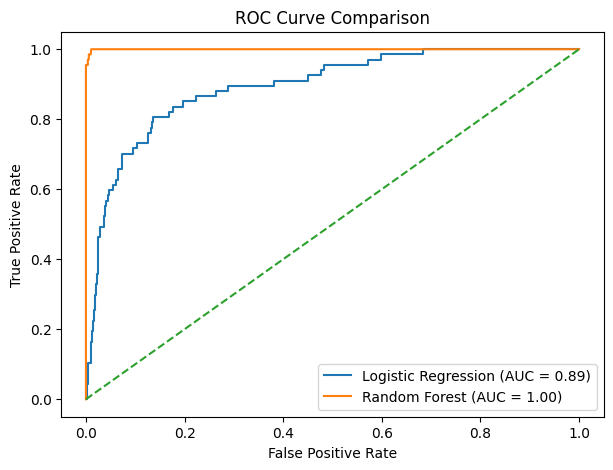

In [ ]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC Score": [lr_auc, rf_auc]
})

results

,Model,ROC-AUC Score
0,Logistic Regression,0.894259
1,Random Forest,0.999702
